# 060. Text Generation - next word 예측

- next word 예측 model 
    - n : 1 model


- old irish lyric 을 corpus 로 이용하여 word index 구성

In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, LSTM, Embedding, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import numpy as np

### corpus data

- Irish song data 이용  


- model 완성 후 동일한 process 를 한글 어린왕자 data 로 수행

In [3]:
file_path = tf.keras.utils.get_file("irish-lyrics-eof.txt", 
                                   "https://github.com/ironmanciti/NLP_lecture/raw/master/data/irish-lyrics-eof.txt")

73728/68970 [================================] - 0s 1us/step


In [4]:
data = open(file_path, "r").read()
#data = open("data/young_prince.txt", "r", encoding="utf-8").read()
data[:150]

'Come all ye maidens young and fair\nAnd you that are blooming in your prime\nAlways beware and keep your garden fair\nLet no man steal away your thyme\nFo'

**\n 을 기준으로 sentence 분리**

In [5]:
corpus = data.lower().split('\n')
corpus[:5]

['come all ye maidens young and fair',
 'and you that are blooming in your prime',
 'always beware and keep your garden fair',
 'let no man steal away your thyme',
 'for thyme it is a precious thing']

### Tokenizer 객체 구성

- num_words : default 는 most common num_words - 1
- filters : default 는 모든 구둣점

In [5]:
tokenizer = Tokenizer(oov_token="<OOV>")

tokenizer.fit_on_texts(corpus)
word2idx = tokenizer.word_index

print("word index 길이 =", len(word2idx))
print(list(word2idx.items())[:10])

word index 길이 = 2690
[('<OOV>', 1), ('the', 2), ('and', 3), ('i', 4), ('to', 5), ('a', 6), ('of', 7), ('my', 8), ('in', 9), ('me', 10)]


### input sentence 를 sequence 로 변환

In [6]:
input_sequences = tokenizer.texts_to_sequences(corpus)
print(input_sequences[:5])

[[52, 13, 97, 1218, 49, 3, 70], [3, 12, 16, 32, 362, 9, 25, 1219], [273, 799, 3, 205, 25, 580, 70], [119, 36, 120, 800, 57, 25, 185], [11, 185, 26, 24, 6, 581, 457]]


### word 단위의 text generation 은 next word 를 예측할 수 있는 형태로 변환

In [7]:
print(tokenizer.texts_to_sequences([corpus[0]]))
print(tokenizer.texts_to_sequences([corpus[1]]))

[[52, 13, 97, 1218, 49, 3, 70]]
[[3, 12, 16, 32, 362, 9, 25, 1219]]


In [8]:
input_sequences = []

for line in corpus:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):     # input, target pair 를 만들어야 하므로 1 부터 시작
        n_grams = token_list[:i+1]
        input_sequences.append(n_grams)
        
input_sequences[:6]

[[52, 13],
 [52, 13, 97],
 [52, 13, 97, 1218],
 [52, 13, 97, 1218, 49],
 [52, 13, 97, 1218, 49, 3],
 [52, 13, 97, 1218, 49, 3, 70]]

### pad sequences

- keras 의 input 은 동일한 길이이므로 가장 긴 sequence 의 길이에 맞추어 padding  

- 마지막 sequence 가 label 이 될 것이므로 padding='pre' 로 설정

In [9]:
# max sequence length
MAX_SEQUENCE_LEN = max(len(x) for x in input_sequences)
MAX_SEQUENCE_LEN 

16

In [10]:
input_sequences = pad_sequences(input_sequences, maxlen=MAX_SEQUENCE_LEN, padding="pre")
print(input_sequences[:6])

[[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    52   13]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0   52
    13   97]
 [   0    0    0    0    0    0    0    0    0    0    0    0   52   13
    97 1218]
 [   0    0    0    0    0    0    0    0    0    0    0   52   13   97
  1218   49]
 [   0    0    0    0    0    0    0    0    0    0   52   13   97 1218
    49    3]
 [   0    0    0    0    0    0    0    0    0   52   13   97 1218   49
     3   70]]


## input, label 분리 및 one-hot-encoding

- 앞의 sequence 를 보고 next word 를 예측하는 model 이므로 
    - input data 는 input_sequences[:-1],  
    - label 은 input_sequences[-1] 로 분리


In [11]:
xs, labels = input_sequences[:, :-1], input_sequences[:, -1]

print(xs[:7])
print()
print(labels[:7])

[[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    52]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0   52
    13]
 [   0    0    0    0    0    0    0    0    0    0    0    0   52   13
    97]
 [   0    0    0    0    0    0    0    0    0    0    0   52   13   97
  1218]
 [   0    0    0    0    0    0    0    0    0    0   52   13   97 1218
    49]
 [   0    0    0    0    0    0    0    0    0   52   13   97 1218   49
     3]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     3]]

[  13   97 1218   49    3   70   12]


### label 을 one-hot-encoding

- label 은 keras utility 를 사용하여 one hot encoding 한다.    


- num_classes 는 pad_sequences 하며 0 이 추가 되었으므로 len(tokenizer.word_index)+1

In [12]:
num_words = len(tokenizer.word_index)+1

ys = tf.keras.utils.to_categorical(labels, num_classes=num_words)

print(xs.shape)
print(labels.shape)
print(ys.shape)

(12038, 15)
(12038,)
(12038, 2691)


## Model 생성 및 train

- m-to-1 model 이므로 return_sequence=False (default)

In [13]:
model = Sequential()
model.add(Embedding(num_words, 100))
model.add(Bidirectional(LSTM(50)))
model.add(Dense(num_words, activation='softmax'))

adam = Adam(lr=0.01)

model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, None, 100)         269100    
_________________________________________________________________
bidirectional (Bidirectional (None, 100)               60400     
_________________________________________________________________
dense (Dense)                (None, 2691)              271791    
Total params: 601,291
Trainable params: 601,291
Non-trainable params: 0
_________________________________________________________________


In [ ]:
history = model.fit(xs, ys, epochs=50, verbose=1, validation_split=0.2)

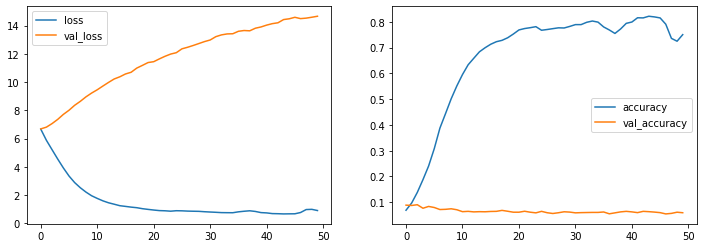

In [15]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='loss')
ax1.plot(history.history['val_loss'], label='val_loss')
ax1.legend()
ax2.plot(history.history['accuracy'], label='accuracy')
ax2.plot(history.history['val_accuracy'], label="val_accuracy")
ax2.legend();

### 학습된 model 을 이용하여 text 생성

In [16]:
next_words = 100

seed_text = "yj went to dublin"

print(tokenizer.word_index.get('yj'))
print(tokenizer.word_index.get('went'))
print(tokenizer.word_index.get('to'))
print(tokenizer.word_index.get('dublin'))

# seed_text = "구렁이 그림을 그린 적이 있다."

# print(tokenizer.word_index.get('구렁이'))
# print(tokenizer.word_index.get('그림을'))
# print(tokenizer.word_index.get('그린'))
# print(tokenizer.word_index.get('적이'))
# print(tokenizer.word_index.get('있다'))

print(tokenizer.texts_to_sequences([seed_text]))

None
174
5
152
[[1, 174, 5, 152]]


**(주의) pad_sequence 의 maxlen 은 마지막 token 을 label 로 사용했으므로 MAX_SEQUENCE_LEN - 1 이다.**

In [17]:
idx2word = dict((i, c) for (c, i) in word2idx.items())

for _ in range(next_words):
    
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=MAX_SEQUENCE_LEN - 1, padding='pre')
    
    predicted = model.predict_classes(token_list)
    output_word = idx2word[predicted[0]]
    
    seed_text += " " + output_word
    
seed_text

'yj went to dublin next arrived i thought her wedding one may court her voice and a tiny trace rising rising barney and out best didnt forget rosie love by the dead and gone and love the love and i love the ground whereon he goes to take them oer the tree to her coffee and my mind so grand gentle a love and i heard a fine old ireland were gone and dont tease me my mother love by the dead and gone and the leaves are green and its too much i suppose i will be my love forever early gone and'